In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.nn import CrossEntropyLoss, MSELoss
from torch.optim import Adam
import cv2
import glob
import os
from pathlib import Path
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

In [2]:
BASE_PATH = "/kaggle/input/garbageclassification/GARBAGECLASSIFICATION"  
TRAIN_IMAGES = os.path.join(BASE_PATH, "train/images")
TRAIN_LABELS = os.path.join(BASE_PATH, "train/labels")
TEST_IMAGES = os.path.join(BASE_PATH, "test/images")
TEST_LABELS = os.path.join(BASE_PATH, "test/labels")

BASE_OUTPUT = "/kaggle/working/"
MODEL_PATH = os.path.join(BASE_OUTPUT, "models", "detector.pth")
PLOTS_PATH = os.path.join(BASE_OUTPUT, "plots")
TEST_PATHS = os.path.join(BASE_OUTPUT, "test_paths.txt")

os.makedirs(BASE_OUTPUT, exist_ok=True)
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(PLOTS_PATH, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PIN_MEMORY = True if DEVICE == "cuda" else False

MEAN = [0.7338, 0.7038, 0.6645]
STD = [0.1803, 0.1876, 0.2085]

INIT_LR = 10e-4
NUM_EPOCHS = 100
BATCH_SIZE = 16

LABELS = 1.0
BBOX = 1.0  

CLASS_NAMES = {
    0: 'BIODEGRADABLE',
    1: 'CARDBOARD',
    2: 'GLASS',
    3: 'METAL',
    4: 'PAPER',
    5: 'PLASTIC'
}

print(f"device: {DEVICE}")
print(f"Output directory: {BASE_OUTPUT}")



device: cuda
Output directory: /kaggle/working/


In [3]:
class CustomTensorDataset(Dataset):
    def __init__(self, img_dir, label_dir, transforms=None):

        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transforms = transforms
        self.img_paths = []
        
        
        all_imgs = sorted(glob.glob(os.path.join(img_dir, "*.jpg")))
        
        for img_path in all_imgs:
            label_path= self._get_label_path(img_path)
            if os.path.exists(label_path):
                self.img_paths.append(img_path)
        print(f"no of images: {len(self.img_paths)}")


    def _get_label_path(self, img_path):
        basename = os.path.basename(img_path).replace('.jpg', '.txt')
        return os.path.join(self.label_dir, basename)

    def _yolo_to_tlbr(self, x_center, y_center, width, height, img_w, img_h):
            x_px= x_center* img_w
            y_px= y_center* img_h
            w_px=width* img_w
            h_px=height* img_h

            startX = (x_px- w_px/2) / img_w
            startY = (y_px- h_px/2) / img_h
            endX = (x_px+ w_px/2) / img_w
            endY = (y_px+ h_px/2) / img_h

            startX = max(0, min(1, startX))
            startY = max(0, min(1, startY))
            endX = max(0, min(1, endX))
            endY = max(0, min(1, endY))
            return startX, startY, endX, endY
    
    def __getitem__(self, idx):
        
        img_path = self.img_paths[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        
        label_path = self._get_label_path(img_path)
        with open(label_path) as f:
            line = f.readline().strip().split()
            class_id = int(line[0])
            x_center, y_center, width, height = map(float, line[1:5])
        
        
        startX, startY, endX, endY = self._yolo_to_tlbr(x_center, y_center, width, height, w, h)
        
        
        image = cv2.resize(image, (224, 224))
        image = transforms.ToTensor()(image)
        bbox = torch.tensor([startX, startY, endX, endY], dtype=torch.float32)
        label = torch.tensor(class_id, dtype=torch.long)
        
        if self.transforms:
            image = self.transforms(image)
        
        return image, label, bbox
    
    def __len__(self):
        return len(self.img_paths)


In [4]:
class ObjectDetector(nn.Module):
    def __init__(self, in_channels=3, out_channels=6, bbox=4):
        super().__init__()
        channel1 = 32
        channel2 = 64
        channel3 = 128
        
        self.conv1 = nn.Conv2d(in_channels, channel1, kernel_size=3, padding=1, stride=1)
        self.conv2 = nn.Conv2d(channel1, channel2, kernel_size=3, padding=1, stride=1)
        self.conv3 = nn.Conv2d(channel2, channel2, kernel_size=3, padding=1, stride=1)
        self.conv4 = nn.Conv2d(channel2, channel3, kernel_size=3, padding=1, stride=1)
        
        self.batchnorm1 = nn.BatchNorm2d(channel1)
        self.batchnorm2 = nn.BatchNorm2d(channel2)
        self.batchnorm3 = nn.BatchNorm2d(channel3)
        
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        
        self.classifier_head = nn.Linear(100352, 6)  
        self.regressor_head = nn.Linear(100352, 4)
    
    def conv_block(self, x):
        x = self.relu(x)
        x = self.maxpool(x)
        return x
    
    def feature_extractor(self, x):
        x = self.conv1(x)
        x = self.batchnorm1(x)
        x = self.conv_block(x)
        
        x = self.conv2(x)
        x = self.batchnorm2(x)
        x = self.conv_block(x)
        
        x = self.conv4(x)
        x = self.batchnorm3(x)
        x = self.conv_block(x)
        
        x = self.flatten(x)
        return x
    
    def forward(self, x):
        x = self.feature_extractor(x)           
        x = self.flatten(x)
        classifier = self.classifier_head(x)
        regressor = self.regressor_head(x)
        return regressor, classifier


In [5]:
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

class_counts = [348, 626, 897, 514, 907, 291]  
total = sum(class_counts)
weights = [total / (len(class_counts) * count) for count in class_counts]
class_weights = torch.FloatTensor(weights).to(DEVICE)
print(f"[INFO] Class weights: {weights}")

trainDS = CustomTensorDataset(
    img_dir=TRAIN_IMAGES,  
    label_dir=TRAIN_LABELS,
    transforms=train_transforms
)
testDS = CustomTensorDataset(
    img_dir=TEST_IMAGES,
    label_dir=TEST_LABELS,
    transforms=val_transforms
)

trainLoader = DataLoader(trainDS, batch_size=32, shuffle=True, 
                        num_workers=2, pin_memory=PIN_MEMORY) 
testLoader = DataLoader(testDS, batch_size=32, 
                       num_workers=2, pin_memory=PIN_MEMORY)  

trainSteps = len(trainDS) // 32
valSteps = len(testDS) // 32

print(f"Train: {len(trainDS)}, Test: {len(testDS)}")


[INFO] Class weights: [1.7159961685823755, 0.9539403620873269, 0.6657376439985135, 1.1618028534370948, 0.6583976479235575, 2.052119129438717]
no of images: 3583
no of images: 1498
Train: 3583, Test: 1498


[INFO] training the network...


  1%|          | 1/100 [00:45<1:15:38, 45.84s/it]


[INFO] EPOCH: 1/100
Train loss: 76.914337, Train accuracy: 0.2908
Val loss: 13.747708, Val accuracy: 0.2710
[INFO] Saved best model at epoch 1


  2%|▏         | 2/100 [01:12<56:14, 34.43s/it]  


[INFO] EPOCH: 2/100
Train loss: 5.993424, Train accuracy: 0.3522
Val loss: 3.935643, Val accuracy: 0.4012
[INFO] Saved best model at epoch 2


...

 93%|█████████▎| 93/100 [41:04<03:01, 25.91s/it]


[INFO] EPOCH: 93/100
Train loss: 0.715526, Train accuracy: 0.7368
Val loss: 1.197315, Val accuracy: 0.6549
[INFO] No improvement (19/20)


 93%|█████████▎| 93/100 [41:30<03:07, 26.78s/it]


[INFO] EPOCH: 94/100
Train loss: 0.715278, Train accuracy: 0.7430
Val loss: 1.205786, Val accuracy: 0.6328
[INFO] No improvement (20/20)
[INFO] Early stopping triggered at epoch 94

[INFO] Total training time: 41.51 minutes
[INFO] Best validation loss: 1.070199


[INFO] Training plot saved to /kaggle/working/plots/training.png


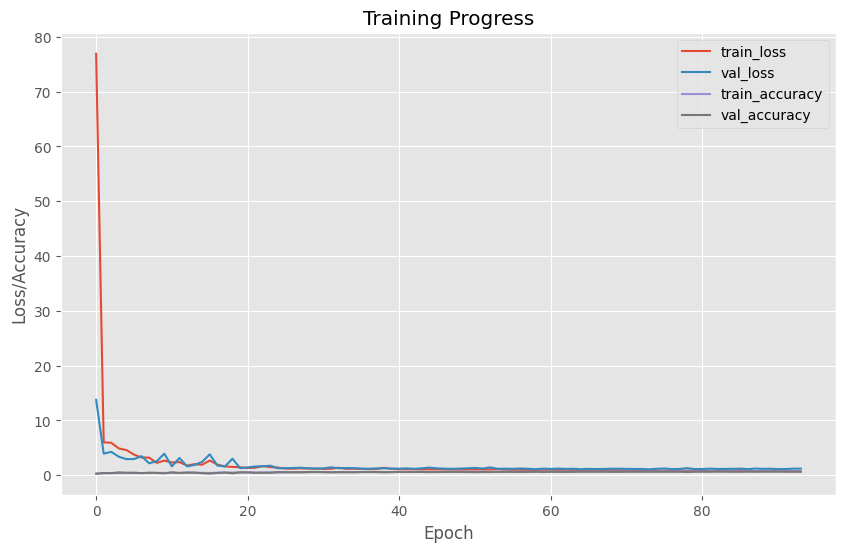

In [6]:
model = ObjectDetector(in_channels=3, out_channels=6, bbox=4)
model = model.to(DEVICE)

classLossFunc = nn.CrossEntropyLoss(weight=class_weights)
bboxLossFunc = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=INIT_LR)

best_val_loss = float('inf')
patience = 20
patience_counter = 0

H = {"total_train_loss": [], "total_val_loss": [], 
     "train_class_acc": [], "val_class_acc": []}

print("[INFO] training the network...")
startTime = time.time()

for e in tqdm(range(NUM_EPOCHS)):
    model.train()
    totalTrainLoss = 0
    totalValLoss = 0
    trainCorrect = 0
    valCorrect = 0

    for (images, labels, bboxes) in trainLoader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        bboxes = bboxes.to(DEVICE)
        
        predictions = model(images)
        bboxLoss = bboxLossFunc(predictions[0], bboxes)
        classLoss = classLossFunc(predictions[1], labels)
        totalLoss = (BBOX * bboxLoss) + (LABELS * classLoss)
        
        opt.zero_grad()
        totalLoss.backward()
        opt.step()

        totalTrainLoss += totalLoss
        trainCorrect += (predictions[1].argmax(1) == labels).sum().item()

    with torch.no_grad():
        model.eval()
        
        for (images, labels, bboxes) in testLoader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            bboxes = bboxes.to(DEVICE)
            
            predictions = model(images)
            bboxLoss = bboxLossFunc(predictions[0], bboxes)
            classLoss = classLossFunc(predictions[1], labels)
            totalLoss = (BBOX * bboxLoss) + (LABELS * classLoss)
            
            totalValLoss += totalLoss
            valCorrect += (predictions[1].argmax(1) == labels).sum().item()

    avgTrainLoss = totalTrainLoss / trainSteps
    avgValLoss = totalValLoss / valSteps
    trainCorrect = trainCorrect / len(trainDS)
    valCorrect = valCorrect / len(testDS)

    H["total_train_loss"].append(avgTrainLoss.cpu().detach().numpy())
    H["train_class_acc"].append(trainCorrect)
    H["total_val_loss"].append(avgValLoss.cpu().detach().numpy())
    H["val_class_acc"].append(valCorrect)

    print(f"\n[INFO] EPOCH: {e + 1}/{NUM_EPOCHS}")
    print(f"Train loss: {avgTrainLoss:.6f}, Train accuracy: {trainCorrect:.4f}")
    print(f"Val loss: {avgValLoss:.6f}, Val accuracy: {valCorrect:.4f}")

    if avgValLoss < best_val_loss:
        best_val_loss = avgValLoss
        torch.save(model, MODEL_PATH)
        patience_counter = 0
        print(f"[INFO] Saved best model at epoch {e+1}")
    else:
        patience_counter += 1
        print(f"[INFO] No improvement ({patience_counter}/{patience})")
    
    if patience_counter >= patience:
        print(f"[INFO] Early stopping triggered at epoch {e+1}")
        break

endTime = time.time()
print(f"\n[INFO] Total training time: {(endTime - startTime)/60:.2f} minutes")
print(f"[INFO] Best validation loss: {best_val_loss:.6f}")

plt.style.use("ggplot")
plt.figure(figsize=(10, 6))
plt.plot(H["total_train_loss"], label="train_loss")
plt.plot(H["total_val_loss"], label="val_loss")
plt.plot(H["train_class_acc"], label="train_accuracy")
plt.plot(H["val_class_acc"], label="val_accuracy")
plt.title("Training Progress")
plt.xlabel("Epoch")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="best")
plt.grid(True)

plotPath = os.path.join(PLOTS_PATH, "training.png")
plt.savefig(plotPath)
print(f"[INFO] Training plot saved to {plotPath}")
